<a href="https://colab.research.google.com/github/DhanushSGouda/ML_LAB/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [2]:
# Generate sample data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head()

,Feature1,Feature2
0,-9.389561,6.303710
1,-9.870824,6.862056
2,-1.522144,7.549274
3,-7.140845,-5.561577
4,-11.284077,6.113819


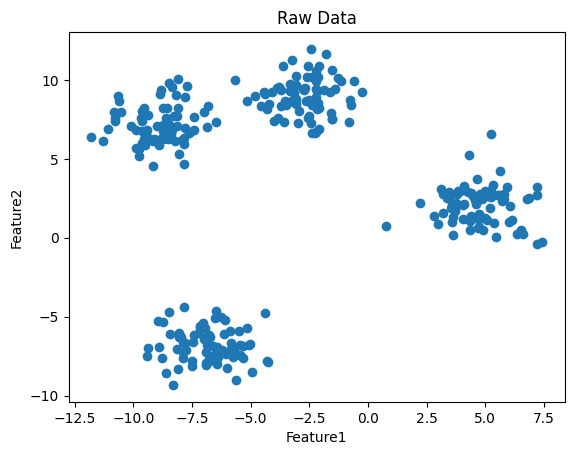

In [3]:
plt.scatter(df['Feature1'], df['Feature2'])
plt.title("Raw Data")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

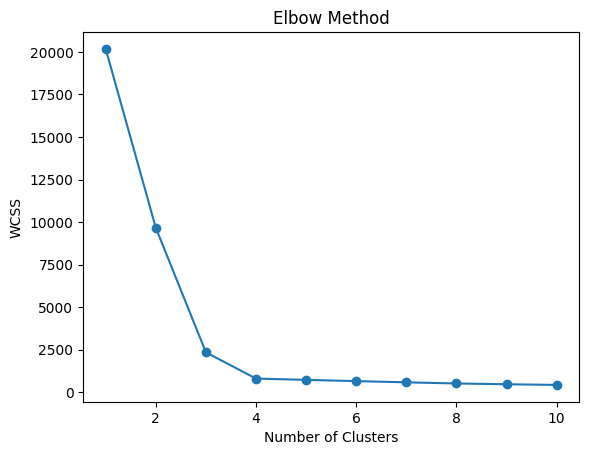

In [4]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

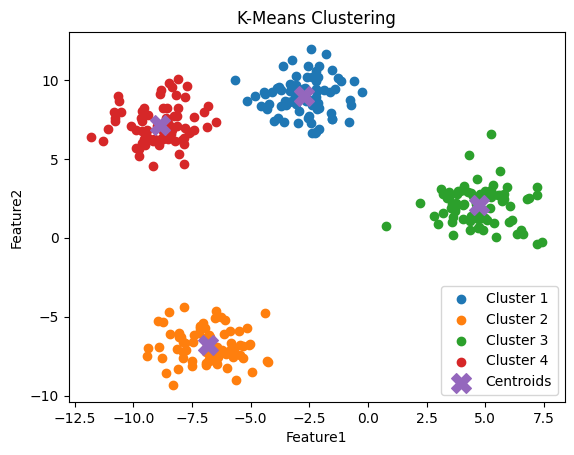

In [6]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], label='Cluster 4')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.show()

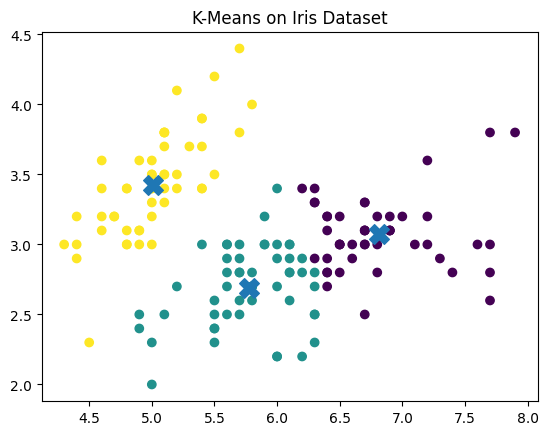

In [7]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, :2]  # take only 2 features for visualization

kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means on Iris Dataset")
plt.show()